# Import thư viện

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

GET DATA FROM YAHOO

In [ ]:

# ==== CẤU HÌNH ====
TICKER = "FPT"        
START_DATE = "2015-10-01"
END_DATE   = "2025-10-01"

# ==== TẢI DỮ LIỆU ====
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,     
    progress=False
)

# ==== CHUẨN HÓA ====
df = df.reset_index()                     # đưa Date từ index thành cột
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ==== LƯU FILE CHUẨN ====
df.to_csv("df_clean.csv", index=False)

# ==== KIỂM TRA ====
print(f"Tải thành công dữ liệu {TICKER}: {len(df)} dòng từ {df['Date'].min().date()} đến {df['Date'].max().date()}")
display(df.head())

Tải thành công dữ liệu FPT: 1607 dòng từ 2015-10-01 đến 2022-03-02


Price,Date,Open,High,Low,Close,Volume
Ticker,,FPT,FPT,FPT,FPT,FPT
0,2015-10-01,26599.500000,26719.099609,26539.699219,26659.300781,300246
1,2015-10-02,26659.300781,26659.300781,26659.300781,26659.300781,0
2,2015-10-05,26719.099609,26958.199219,26659.300781,26898.400391,639807
3,2015-10-06,27257.000000,27615.699219,27137.500000,27496.099609,1545683
4,2015-10-07,27615.699219,27615.699219,26898.400391,27017.900391,564875


ANALIZING AND PREPROCESSING DATA

In [5]:
df.head()

Price,Date,Open,High,Low,Close,Volume
Ticker,,FPT,FPT,FPT,FPT,FPT
0,2015-10-01,26599.500000,26719.099609,26539.699219,26659.300781,300246
1,2015-10-02,26659.300781,26659.300781,26659.300781,26659.300781,0
2,2015-10-05,26719.099609,26958.199219,26659.300781,26898.400391,639807
3,2015-10-06,27257.000000,27615.699219,27137.500000,27496.099609,1545683
4,2015-10-07,27615.699219,27615.699219,26898.400391,27017.900391,564875


In [6]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1607 entries, 0 to 1606
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   (Date, )       1607 non-null   datetime64[ns]
 1   (Open, FPT)    1607 non-null   float64       
 2   (High, FPT)    1607 non-null   float64       
 3   (Low, FPT)     1607 non-null   float64       
 4   (Close, FPT)   1607 non-null   float64       
 5   (Volume, FPT)  1607 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 75.5 KB


Price,Date,Open,High,Low,Close,Volume
Ticker,,FPT,FPT,FPT,FPT,FPT
count,1607,1607.000000,1607.000000,1607.000000,1607.000000,1.607000e+03
mean,2018-12-10 14:19:20.423148544,48753.982207,49228.962538,48336.915881,48767.011792,1.641815e+06
min,2015-10-01 00:00:00,26599.500000,26659.300781,26480.000000,26659.300781,0.000000e+00
25%,2017-05-06 12:00:00,32737.600586,33150.000000,32565.750000,32857.898438,6.508800e+05
50%,2018-12-10 00:00:00,44090.898438,44521.699219,43500.000000,44087.000000,1.130805e+06
75%,2020-07-15 12:00:00,55150.000000,55800.000000,54750.000000,55250.000000,1.884248e+06
max,2022-03-02 00:00:00,100100.000000,101500.000000,99400.000000,99400.000000,2.277800e+08
std,NaN,19853.068804,20030.438897,19685.032825,19859.450543,6.783475e+06


Data Cleaning

In [7]:
# --- DATA CLEANING ----------------------------------------------------------

df = df.copy()

# 1. Parse Date & sort - Correctly accessing multi-level index for Date
df[('Date', '')] = pd.to_datetime(df[('Date', '')], errors="coerce")
df = (
    df.dropna(subset=[('Date', '')])
      .sort_values(('Date', ''))
      .reset_index(drop=True)
)

# Flatten the column names after handling the Date column
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns.values]


# 2. Xử lý trùng lặp theo ngày (nếu 1 ngày có nhiều dòng -> giữ dòng Volume lớn nhất)
df = (
    df.sort_values(["Date", "Volume"])
      .groupby("Date", as_index=False)
      .tail(1)
      .reset_index(drop=True)
)

# 3. Ép kiểu numeric và loại lỗi cơ bản
for c in ["Open", "High", "Low", "Close", "Volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[
    (df[["Open","High","Low","Close"]].gt(0).all(axis=1)) &
    (df["Volume"] >= 0)
].dropna(subset=["Open","High","Low","Close","Volume"])

# 4. Kiểm tra hợp lý giá trong ngày
df = df[
    (df["High"] >= df[["Open","Close","Low"]].max(axis=1)) &
    (df["Low"]  <= df[["Open","Close","High"]].min(axis=1))
]

# 5. Chuẩn hoá đơn vị Volume nếu quá lớn
if df["Volume"].max() > 1e7:
    df["Volume"] = df["Volume"] / 1e6   # chuyển về triệu
    df["Volume_unit"] = "million_shares"
else:
    df["Volume_unit"] = "raw"

# 6. Phát hiện khả năng chia tách cổ phiếu (split)
ratio = df["Close"] / df["Close"].shift(1)
possible_split = ratio.round(2).isin([0.5, 0.33, 2.0, 3.0])
df["possible_split"] = possible_split.fillna(False)

# 7. Kết quả
print("Số dòng sau làm sạch:", len(df))
display(df.head())

# lưu lại làm chuẩn cho bước feature
df.to_csv("df_clean_after_cleaning.csv", index=False)

Số dòng sau làm sạch: 1606


,Date,Open,High,Low,Close,Volume,Volume_unit,possible_split
0,2015-10-01,26599.500000,26719.099609,26539.699219,26659.300781,0.300246,million_shares,False
1,2015-10-02,26659.300781,26659.300781,26659.300781,26659.300781,0.000000,million_shares,False
2,2015-10-05,26719.099609,26958.199219,26659.300781,26898.400391,0.639807,million_shares,False
3,2015-10-06,27257.000000,27615.699219,27137.500000,27496.099609,1.545683,million_shares,False
4,2015-10-07,27615.699219,27615.699219,26898.400391,27017.900391,0.564875,million_shares,False


DATA ANALYSIS

In [8]:
# ---- CÂU 1: Xu hướng giá đóng cửa theo năm ----
tmp = df.copy()
tmp['Year'] = tmp['Date'].dt.year

annual_avg = (
    tmp.groupby('Year', as_index=False)['Close']
       .mean()
       .rename(columns={'Close': 'Avg_Close'})
)
annual_avg['Pct_Change'] = annual_avg['Avg_Close'].pct_change() * 100
annual_avg['Trend'] = np.select(
    [annual_avg['Pct_Change'] > 0, annual_avg['Pct_Change'] < 0],
    ['Increase', 'Decrease'],
    default='No change'
)
display(annual_avg)

,Year,Avg_Close,Pct_Change,Trend
0,2015,29097.896790,NaN,No change
1,2016,29038.623070,-0.203704,Decrease
2,2017,36398.166171,25.343981,Increase
3,2018,42713.557037,17.350849,Increase
4,2019,48411.582140,13.340086,Increase
5,2020,49512.536391,2.274155,Increase
6,2021,85995.370888,73.684035,Increase
7,2022,90758.333333,5.538627,Increase


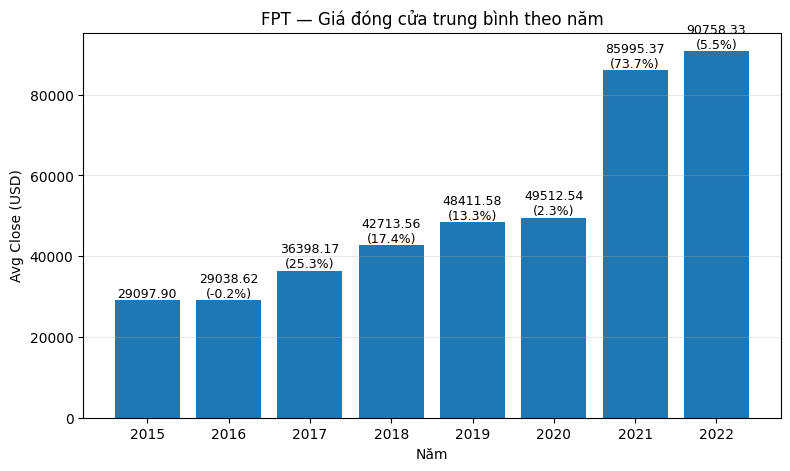

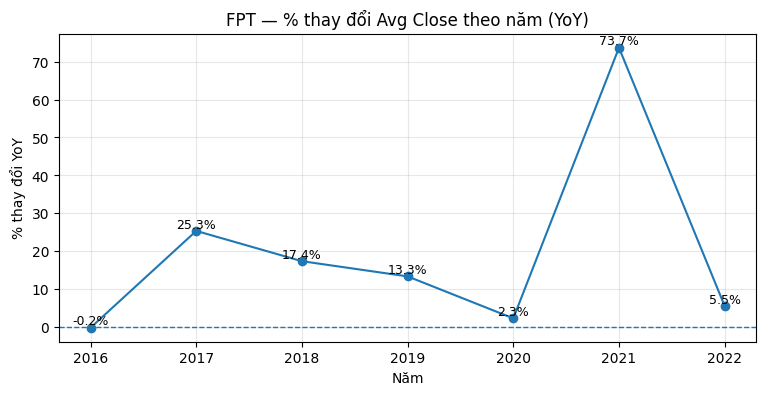

In [9]:
# --- Biểu đồ 1: Giá đóng cửa trung bình theo năm (bar) ---
plt.figure(figsize=(9,5))

# Simplify column names for plotting
annual_avg.columns = ['Year', 'Avg_Close', 'Pct_Change', 'Trend']

plt.bar(annual_avg['Year'], annual_avg['Avg_Close'])
plt.title('FPT — Giá đóng cửa trung bình theo năm')
plt.xlabel('Năm')
plt.ylabel('Avg Close (USD)')
plt.grid(axis='y', alpha=0.3)

# ghi nhãn giá trị & % thay đổi lên đầu cột (nếu có)
for y, v, pct in zip(annual_avg['Year'], annual_avg['Avg_Close'], annual_avg['Pct_Change']):
    label = f"{v:.2f}"
    if pd.notna(pct):
        label += f"\n({pct:.1f}%)"
    plt.text(y, v, label, ha='center', va='bottom', fontsize=9)

plt.show()

# --- Biểu đồ 2: % thay đổi YoY (line) ---
plt.figure(figsize=(9,4))
plt.plot(annual_avg['Year'], annual_avg['Pct_Change'], marker='o')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('FPT — % thay đổi Avg Close theo năm (YoY)')
plt.xlabel('Năm')
plt.ylabel('% thay đổi YoY')
plt.grid(alpha=0.3)
for y, pct in zip(annual_avg['Year'], annual_avg['Pct_Change']):
    if pd.notna(pct):
        plt.text(y, pct, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

plt.show()

 Thống kê lợi suất hằng ngày:
- Trung bình (Mean): 0.092%
- Độ lệch chuẩn (Volatility): 1.665%
- Skew (Lệch): -0.240
- Kurtosis (Độ nhọn): 11.684


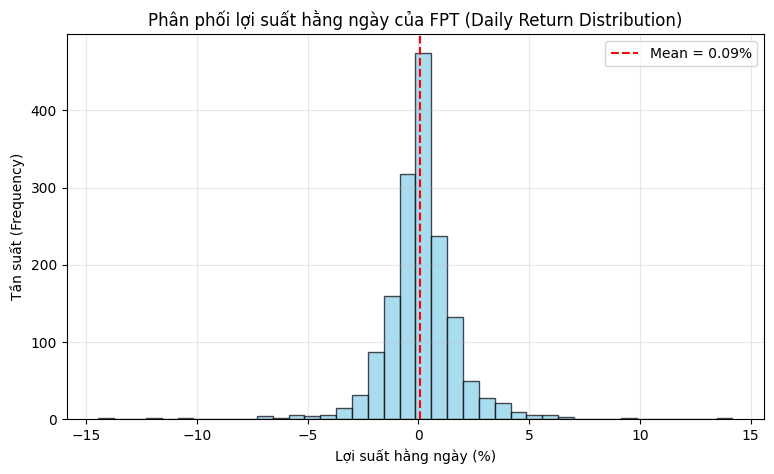

In [10]:
# ---- Câu 2: Phân phối lợi suất hằng ngày (Daily Returns) ----
df_return = df.copy()
df_return['Daily_Return'] = df_return['Close'].pct_change() * 100

# Loại bỏ giá trị NaN đầu tiên
returns = df_return['Daily_Return'].dropna()

# Tính thống kê cơ bản
mean_ret = returns.mean()
std_ret = returns.std()
skew_ret = returns.skew()
kurt_ret = returns.kurt()

print(" Thống kê lợi suất hằng ngày:")
print(f"- Trung bình (Mean): {mean_ret:.3f}%")
print(f"- Độ lệch chuẩn (Volatility): {std_ret:.3f}%")
print(f"- Skew (Lệch): {skew_ret:.3f}")
print(f"- Kurtosis (Độ nhọn): {kurt_ret:.3f}")

# --- Vẽ histogram ---
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.hist(returns, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_ret, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_ret:.2f}%")
plt.title("Phân phối lợi suất hằng ngày của FPT (Daily Return Distribution)")
plt.xlabel("Lợi suất hằng ngày (%)")
plt.ylabel("Tần suất (Frequency)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# --- FEATURE ENGINEERING -------------------------------------------------------
df_feat = df.copy()

# 1. Lợi suất hằng ngày
df_feat["return"] = df_feat["Close"].pct_change()

# 2. Biên độ dao động trong ngày
df_feat["intraday_range"] = (df_feat["High"] - df_feat["Low"]) / df_feat["Close"]

# 3. Chênh lệch giá mở - đóng
df_feat["close_open_ret"] = (df_feat["Close"] - df_feat["Open"]) / df_feat["Open"]

# 4. Tỷ lệ khối lượng so với trung vị 120 ngày
df_feat["vol_ratio"] = df_feat["Volume"] / df_feat["Volume"].rolling(120).median()

# 5. Z-score khối lượng (chuẩn hóa)
rolling_mean_vol = df_feat["Volume"].rolling(120).mean()
rolling_std_vol  = df_feat["Volume"].rolling(120).std()
df_feat["vol_z"] = (df_feat["Volume"] - rolling_mean_vol) / rolling_std_vol

# 6. Z-score lợi suất
rolling_mean_ret = df_feat["return"].rolling(120).mean()
rolling_std_ret  = df_feat["return"].rolling(120).std()
df_feat["ret_z"] = (df_feat["return"] - rolling_mean_ret) / rolling_std_ret

# 7. Độ biến động ngắn hạn
df_feat["volatility"] = df_feat["return"].rolling(20).std()

# 8. % thay đổi giá 1,3,5 ngày sau
for n in [1, 3, 5]:
    df_feat[f"price_move_{n}d"] = df_feat["Close"].pct_change(periods=n).shift(-n)

# 9. Chỉ số phối hợp giá–khối lượng
df_feat["price_move_pct"] = df_feat["Close"].pct_change(periods=1).shift(-1)
df_feat["combined_anomaly"] = df_feat["price_move_pct"] * df_feat["vol_z"]

# 10. Loại NaN đầu kỳ (do rolling)
df_feat = df_feat.dropna().reset_index(drop=True)

print("Số dòng sau khi tạo đặc trưng:", len(df_feat))
display(df_feat.head())

Số dòng sau khi tạo đặc trưng: 1481


,Date,Open,High,Low,Close,Volume,Volume_unit,possible_split,return,intraday_range,close_open_ret,vol_ratio,vol_z,ret_z,volatility,price_move_1d,price_move_3d,price_move_5d,price_move_pct,combined_anomaly
0,2016-03-24,29169.800781,29229.599609,28930.699219,28930.699219,1.391804,million_shares,False,-0.006159,0.010332,-0.008197,1.178469,-0.188408,-0.488808,0.006956,-0.008265,-0.018596,-0.033058,-0.008265,0.001557
1,2016-03-28,28870.900391,28870.900391,28631.800781,28691.599609,0.672681,million_shares,False,-0.008265,0.008333,-0.006210,0.569573,-0.732484,-0.631174,0.007239,-0.010418,-0.018748,-0.025000,-0.010418,0.007631
2,2016-03-29,28691.599609,28691.599609,28333.000000,28392.699219,1.223102,million_shares,False,-0.010418,0.012630,-0.010418,1.024085,-0.324149,-0.770375,0.007610,0.000000,-0.014736,-0.010524,0.000000,-0.000000
3,2016-03-30,28392.699219,28631.800781,28213.400391,28392.699219,0.996951,million_shares,False,0.000000,0.014736,0.000000,0.844139,-0.490100,-0.025880,0.007334,-0.008418,-0.014736,-0.002103,-0.008418,0.004125
4,2016-03-31,28392.699219,28691.599609,28153.699219,28153.699219,1.042473,million_shares,False,-0.008418,0.019106,-0.008418,0.882683,-0.459810,-0.631532,0.007038,-0.006372,-0.002124,0.014861,-0.006372,0.002930


In [12]:
# --- ANOMALY DETECTION --------------------------------------------------------
df_anom = df_feat.copy()

# Z của intraday_range để chuẩn hóa thêm 1 kênh biến động
intra_mean = df_anom["intraday_range"].rolling(60).mean()
intra_std  = df_anom["intraday_range"].rolling(60).std()
df_anom["intra_z"] = (df_anom["intraday_range"] - intra_mean) / intra_std

# 1) Điểm tổng hợp đơn giản (giá–khối lượng–biên độ)
df_anom["anomaly_score"] = (
    0.5*df_anom["vol_z"].abs() +
    0.3*df_anom["ret_z"].abs() +
    0.2*df_anom["intra_z"].abs()
)

# 2) Phân mức theo rule z-score
high_rule = (
    (df_anom["ret_z"].abs() >= 3.5)
    | ((df_anom["vol_z"].abs() >= 3.5) & (df_anom["close_open_ret"].abs() >= 0.07))
)
med_rule = (
    (df_anom["ret_z"].abs().between(2, 3.5, inclusive="neither"))
    | (df_anom["vol_z"].abs().between(2, 3.5, inclusive="neither"))
    | (df_anom["intraday_range"] >= 0.07)
)
low_rule = (
    (df_anom["ret_z"].abs().between(1.8, 2.5, inclusive="both"))
    | (df_anom["vol_z"].abs().between(1.8, 2.5, inclusive="both"))
)

# 3) Phân vị theo điểm tổng hợp (tùy chọn)
p99_9 = df_anom["anomaly_score"].quantile(0.999)  # top 0.1% -> High
p99   = df_anom["anomaly_score"].quantile(0.99)   # 0.1–1% -> Medium

# 4) Gán mức cuối cùng (lấy mức nặng hơn giữa rule và phân vị)
level = np.where(high_rule | (df_anom["anomaly_score"] >= p99_9), "High",
         np.where(med_rule | (df_anom["anomaly_score"] >= p99), "Medium",
         np.where(low_rule, "Low", "Normal")))
df_anom["anomaly_level"] = level

# Kết quả
display(df_anom[["Date","Close","Volume","ret_z","vol_z","intra_z",
                 "anomaly_score","anomaly_level"]].tail(10))

,Date,Close,Volume,ret_z,vol_z,intra_z,anomaly_score,anomaly_level
1471,2022-02-09,90700.0,1.1427,0.125917,-0.141877,-0.578122,0.224338,Normal
1472,2022-02-10,92000.0,0.9749,1.211847,-0.146223,0.247083,0.486082,Normal
1473,2022-02-11,91600.0,0.6416,-0.347135,-0.158859,-0.715949,0.326759,Normal
1474,2022-02-14,91000.0,0.7741,-0.530968,-0.153030,-0.465071,0.328820,Normal
1475,2022-02-15,91000.0,0.0000,0.021409,-0.184773,-1.856850,0.470179,Normal
1476,2022-02-16,91300.0,0.6142,0.292866,-0.159121,-0.397815,0.246983,Normal
1477,2022-02-17,92800.0,0.8537,1.383276,-0.148651,0.277482,0.544805,Normal
1478,2022-02-18,92200.0,0.6188,-0.547517,-0.156991,-0.873444,0.417440,Normal
1479,2022-02-22,92900.0,1.1582,0.627311,-0.134091,-0.307879,0.316814,Normal
1480,2022-02-23,93000.0,0.9738,0.077857,-0.140920,-0.293998,0.152617,Normal


In [13]:
# --- CLUSTER DETECTION --------------------------------------------------------


gap_days = 1  # cho phép cách nhau tối đa 1 ngày lịch

base = df_anom.copy()
# Flatten multi-level columns
base.columns = [col[0] if isinstance(col, tuple) else col for col in base.columns.values]
base = base.sort_values("Date").reset_index(drop=True)


# 1) Giữ ngày bất thường
mask = base["anomaly_level"].isin(["High", "Medium"])
abn = base.loc[mask, ["Date","Close","return","ret_z","vol_z","anomaly_level"]].copy()

# 2) Tạo cluster_id theo khoảng cách ngày
g = abn["Date"].diff().dt.days.fillna(0).gt(gap_days).cumsum()
abn["cluster_id"] = g.values

# giúp tra cứu close sau cụm
date_to_close = base.set_index("Date")["Close"]

# 3) Tính chỉ số cụm
def cluster_stats(df):
    start = df["Date"].min()
    end   = df["Date"].max()
    length = (end - start).days + 1

    n_high   = (df["anomaly_level"]=="High").sum()
    n_medium = (df["anomaly_level"]=="Medium").sum()

    max_volz = df["vol_z"].abs().max()
    avg_volz = df["vol_z"].abs().mean()
    max_retz = df["ret_z"].abs().max()
    avg_ret  = df["return"].mean()

    # biến động đỉnh trong cụm so với ngày đầu
    start_close = df.loc[df["Date"].idxmin(), "Close"]
    peak_close  = df["Close"].max()
    move_start_to_peak = peak_close/start_close - 1

    # lợi suất sau cụm 1/3/5 ngày
    end_close = df.loc[df["Date"].idxmax(), "Close"]
    post = {}
    for n in (1,3,5):
        fut_date = end + pd.Timedelta(days=n)
        fut_close = date_to_close.reindex([fut_date]).dropna()
        post[f"post_ret_{n}d"] = (fut_close.iloc[0]/end_close - 1) if not fut_close.empty else np.nan

    # tỷ lệ ngày có vol_z >= 2
    share_volz_ge2_val = (df["vol_z"].abs() >= 2).mean() # Use temporary variable

    return pd.Series({
        "start_date": start, "end_date": end, "length_days": length,
        "n_high_days": n_high, "n_medium_days": n_medium,
        "max_vol_z": max_volz, "avg_vol_z": avg_volz,
        "max_ret_z": max_retz, "avg_ret": avg_ret,
        "price_move_from_start_to_peak": move_start_to_peak,
        "post_ret_1d": post["post_ret_1d"],
        "post_ret_3d": post["post_ret_3d"],
        "post_ret_5d": post["post_ret_5d"],
        "share_days_volz_ge2": share_volz_ge2_val, # Use temporary variable here
    })

clusters = abn.groupby("cluster_id", as_index=False).apply(cluster_stats).reset_index(drop=True)

# 4) Phân loại cụm
def label_cluster(r):
    if (r.length_days >= 2) and (r.max_vol_z >= 3) and pd.notna(r.post_ret_3d) and (r.post_ret_3d <= -0.05):
        return "Suspicious"
    if (r.length_days <= 2) and (r.max_vol_z >= 4):
        return "Possible"
    if (r.length_days >= 3) and (1.5 <= r.avg_vol_z <= 2.5):
        return "Watch"
    return "Neutral"

clusters["cluster_label"] = clusters.apply(label_cluster, axis=1)

# 5) Gắn cluster_id vào bảng ngày
base = base.merge(abn[["Date","cluster_id"]], on="Date", how="left")

print("Số cụm:", len(clusters))
display(clusters.head())
# base chứa cột cluster_id để bạn lọc các ngày thuộc từng cụm

Số cụm: 119


C:\Users\Thanh Khiem\AppData\Local\Temp\ipykernel_27712\2357389184.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clusters = abn.groupby("cluster_id", as_index=False).apply(cluster_stats).reset_index(drop=True)


,cluster_id,start_date,end_date,length_days,n_high_days,n_medium_days,max_vol_z,avg_vol_z,max_ret_z,avg_ret,price_move_from_start_to_peak,post_ret_1d,post_ret_3d,post_ret_5d,share_days_volz_ge2,cluster_label
0,0,2016-04-28,2016-04-28,1,0,1,3.126992,3.126992,1.212493,0.014674,0.0,0.004134,NaN,0.004134,1.0,Neutral
1,1,2016-06-20,2016-06-20,1,1,0,2.436103,2.436103,5.660734,0.056930,0.0,0.000000,-0.018735,NaN,1.0,Neutral
2,2,2016-06-24,2016-06-24,1,0,1,3.549915,3.549915,2.313058,-0.023866,0.0,NaN,0.007334,0.026893,1.0,Neutral
3,3,2016-07-07,2016-07-07,1,0,1,1.808958,1.808958,2.255059,0.023641,0.0,0.006928,NaN,-0.016167,0.0,Neutral
4,4,2016-07-11,2016-07-11,1,0,1,0.676385,0.676385,2.316667,-0.022936,0.0,0.000000,0.009388,NaN,0.0,Neutral


In [14]:
# --- PUMP–DUMP DETECTION (simple inline) --------------------------------------
df_pump = df_anom.sort_values("Date").reset_index(drop=True).copy()

# 1. Ngày pump: tăng >3%, vol_z >2.5
df_pump["is_pump"] = (df_pump["return"] >= 0.03) & (df_pump["vol_z"] >= 2.5)

# 2. Gom chuỗi pump liên tiếp
df_pump["pump_id"] = (df_pump["is_pump"].ne(df_pump["is_pump"].shift())).cumsum()
groups = df_pump[df_pump["is_pump"]].groupby("pump_id")

events = []
for pid, g in groups:
    s, e = g.index.min(), g.index.max()
    start = df_pump.loc[s, "Date"]
    end = df_pump.loc[e, "Date"] # Capture end date of the pump event
    start_close = df_pump.loc[s, "Close"]
    peak_close  = g["Close"].max()
    pump_pct = peak_close / start_close - 1
    # Extract scalar date values before subtraction
    time_to_peak = (g.loc[g["Close"].idxmax(), "Date"] - start).days

    # Dump: giảm ≥6% trong 5 ngày sau, vol_z vẫn cao
    after = df_pump.loc[e+1 : e+5]
    if not after.empty:
        end_close = after["Close"].iloc[-1]
        dump_pct = end_close / peak_close - 1
        if (dump_pct.item() <= -0.06) and (after["vol_z"].max() >= 2.5): # Use .item() here
            dump_date = after["Date"].iloc[-1]
            events.append({
                "start_date": start, # Extract scalar
                "peak_date": g.loc[g["Close"].idxmax(), "Date"], # Extract scalar
                "end_date": dump_date,
                "pump_days": e - s + 1,
                "time_to_peak": time_to_peak,
                "time_to_dump": (dump_date - start).days, # Extract scalar
                "pump_pct": pump_pct.item(), # Extract scalar
                "dump_pct": dump_pct.item(), # Extract scalar
                "max_vol_z": g["vol_z"].max(),
                "pattern": "pump_dump"
            })

# 3. Gom kết quả
pump_dump = pd.DataFrame(events)
print("Số mẫu pump–dump phát hiện:", len(pump_dump))
display(pump_dump.head())

Số mẫu pump–dump phát hiện: 0


""


In [15]:
# --- PRICE–VOLUME RELATION CHECK ----------------------------------------------
df_rel = df_anom.copy()

# 1. Chỉ số kết hợp
df_rel["joint_metric"] = df_rel["price_move_pct"] * df_rel["vol_z"]

# 2. Phân loại quan hệ
cond_suspect = (df_rel["vol_z"] >= 3) & (df_rel["ret_z"].abs() <= 0.5)
cond_news    = (df_rel["ret_z"].abs() >= 3) & (df_rel["vol_z"] <= 1)

df_rel["relation_flag"] = np.select(
    [cond_suspect, cond_news],
    ["Suspicious_VolOnly", "Likely_News"],
    default="Normal"
)

# 3. Có thể dùng thêm turnover (Volume × Close)
df_rel["turnover"] = df_rel["Volume"] * df_rel["Close"]

# 4. Kết quả
print("Số ngày nghi ngờ thao túng:", (df_rel["relation_flag"]=="Suspicious_VolOnly").sum())
display(df_rel[["Date","Close","Volume","vol_z","ret_z","joint_metric","relation_flag"]].tail(10))

Số ngày nghi ngờ thao túng: 6


,Date,Close,Volume,vol_z,ret_z,joint_metric,relation_flag
1471,2022-02-09,90700.0,1.1427,-0.141877,0.125917,-0.002034,Normal
1472,2022-02-10,92000.0,0.9749,-0.146223,1.211847,0.000636,Normal
1473,2022-02-11,91600.0,0.6416,-0.158859,-0.347135,0.001041,Normal
1474,2022-02-14,91000.0,0.7741,-0.153030,-0.530968,-0.000000,Normal
1475,2022-02-15,91000.0,0.0000,-0.184773,0.021409,-0.000609,Normal
1476,2022-02-16,91300.0,0.6142,-0.159121,0.292866,-0.002614,Normal
1477,2022-02-17,92800.0,0.8537,-0.148651,1.383276,0.000961,Normal
1478,2022-02-18,92200.0,0.6188,-0.156991,-0.547517,-0.001192,Normal
1479,2022-02-22,92900.0,1.1582,-0.134091,0.627311,-0.000144,Normal
1480,2022-02-23,93000.0,0.9738,-0.140920,0.077857,0.001515,Normal


In [16]:
# --- STAT SIG & ERROR REDUCTION (inline) --------------------------------------
import numpy as np, pandas as pd

rng = np.random.default_rng(0)
X = df_anom[["Date","return","ret_z","vol_z","close_open_ret","anomaly_level","anomaly_score"]].dropna().reset_index(drop=True)

# 1) Permutation p-value cho số ngày High
obs_high = (X["anomaly_level"]=="High").sum()
S = 2000
sim_counts = np.empty(S, dtype=int)
for i in range(S):
    retz  = rng.permutation(X["ret_z"].to_numpy())
    volz  = rng.permutation(X["vol_z"].to_numpy())
    intra = rng.permutation(X["close_open_ret"].to_numpy())
    high = (np.abs(retz) >= 3) | ((np.abs(volz) >= 3) & (np.abs(intra) >= 0.05))
    sim_counts[i] = int(high.sum())
p_value = (np.sum(sim_counts >= obs_high) + 1) / (S + 1)
print(f"Observed HIGH days: {obs_high}")
print(f"Permutation p-value: {p_value:.4f}")

# 2) Tương quan với chỉ số thị trường (tùy chọn)
try:
    import yfinance as yf
    bench = yf.download("^GSPC",
                        start=str(X["Date"].min().date()),
                        end=str(X["Date"].max().date()),
                        auto_adjust=True)[["Close"]].reset_index()
    bench = bench.rename(columns={"Close":"BenchClose"})
    bench["bench_ret"] = bench["BenchClose"].pct_change()

    m = X.merge(bench[["Date","bench_ret"]], on="Date", how="left")
    m["roll_corr20"] = m["return"].rolling(20).corr(m["bench_ret"])
    market_driven = (m["anomaly_level"].isin(["High","Medium"])) & (m["roll_corr20"] >= 0.7)
    print("Market-driven abnormal days (corr>=0.7):", int(market_driven.sum()))
except Exception as e:
    print("Skip benchmark check:", e)

# 3) Quét ngưỡng ret_z, vol_z để chọn ngưỡng
grid = []
for rz in (2.0, 2.5, 3.0):
    for vz in (2.0, 2.5, 3.0):
        high = (X["ret_z"].abs()>=rz) | (X["vol_z"].abs()>=vz)
        grid.append({
            "ret_z_thr": rz,
            "vol_z_thr": vz,
            "count": int(high.sum()),
            "share": float(high.mean()),
            "p90_score": float(X.loc[high, "anomaly_score"].quantile(0.9)) if high.any() else np.nan
        })
tuning_table = pd.DataFrame(grid).sort_values(["ret_z_thr","vol_z_thr"]).reset_index(drop=True)
display(tuning_table)

Observed HIGH days: 16
Permutation p-value: 1.0000


[*********************100%***********************]  1 of 1 completed

Skip benchmark check: Not allowed to merge between different levels. (1 levels on the left, 2 on the right)


,ret_z_thr,vol_z_thr,count,share,p90_score
0,2.0,2.0,152,0.106892,3.214588
1,2.0,2.5,128,0.090014,3.281595
2,2.0,3.0,110,0.077356,3.367629
3,2.5,2.0,121,0.085091,3.321171
4,2.5,2.5,94,0.066104,3.430464
5,2.5,3.0,74,0.052039,3.543215
6,3.0,2.0,110,0.077356,3.367629
7,3.0,2.5,82,0.057665,3.493896
8,3.0,3.0,60,0.042194,3.593363


In [22]:


# --- TỔNG HỢP BẤT THƯỜNG ------------------------------------------------------
from IPython.display import Markdown, display

n_total = len(df_anom)
n_high  = int((df_anom["anomaly_level"]=="High").sum())
n_med   = int((df_anom["anomaly_level"]=="Medium").sum())
n_low   = int((df_anom["anomaly_level"]=="Low").sum())
n_abn   = n_high + n_med + n_low
pct_abn = 100 * n_abn / n_total if n_total else 0.0

# tín hiệu mạnh thêm
n_clusters = int(len(clusters)) if "clusters" in locals() else 0
max_volz   = float(clusters["max_vol_z"].max()) if n_clusters else 0.0
has_pump   = bool(len(pump_dump)) if "pump_dump" in locals() else False

# kết luận
if (n_high >= 10) or (max_volz >= 5) or has_pump:
    conclusion = "Có dấu hiệu thao túng đáng kể."
elif (n_high >= 3) or (n_clusters >= 2):
    conclusion = "Có thể có thao túng, cần theo dõi thêm."
else:
    conclusion = "Không có dấu hiệu thao túng giá đáng kể – biến động trong phạm vi bình thường."

md = f"""
**TỔNG HỢP BẤT THƯỜNG**

- Tổng số ngày bất thường: **{n_abn}**
  - High   : **{n_high}** ngày
  - Medium : **{n_med}** ngày
  - Low    : **{n_low}** ngày

- Tỷ lệ ngày bất thường: **{pct_abn:.2f}%** trên toàn bộ dữ liệu

**KẾT LUẬN:**
{conclusion}
"""
display(Markdown(md))




**TỔNG HỢP BẤT THƯỜNG**

- Tổng số ngày bất thường: **186**
  - High   : **16** ngày
  - Medium : **128** ngày
  - Low    : **42** ngày

- Tỷ lệ ngày bất thường: **12.56%** trên toàn bộ dữ liệu

**KẾT LUẬN:**
Có dấu hiệu thao túng đáng kể.


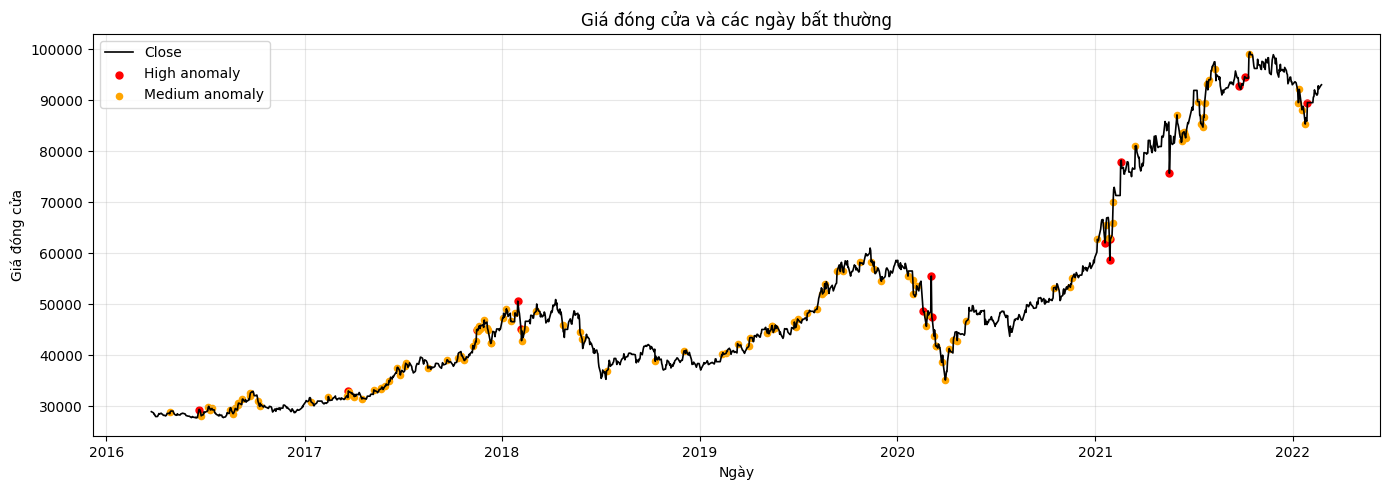

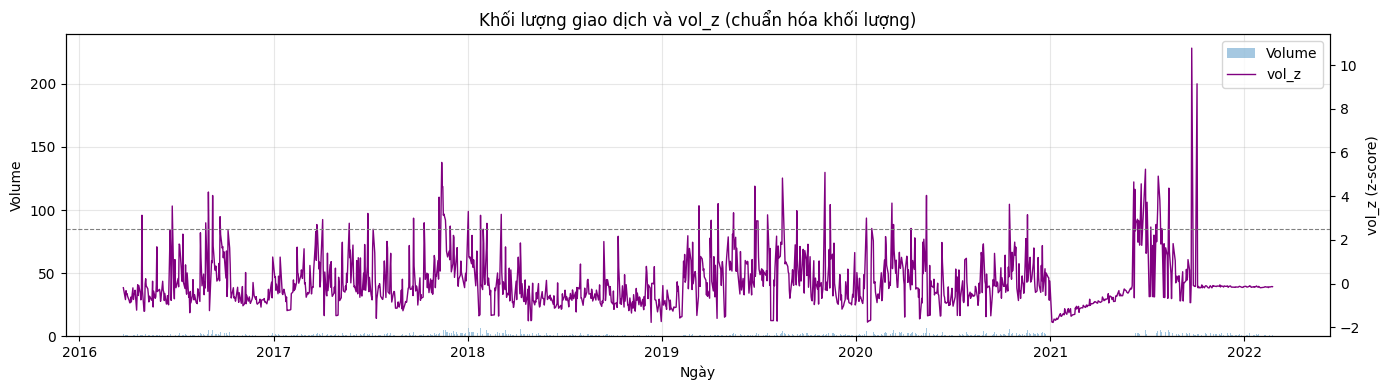

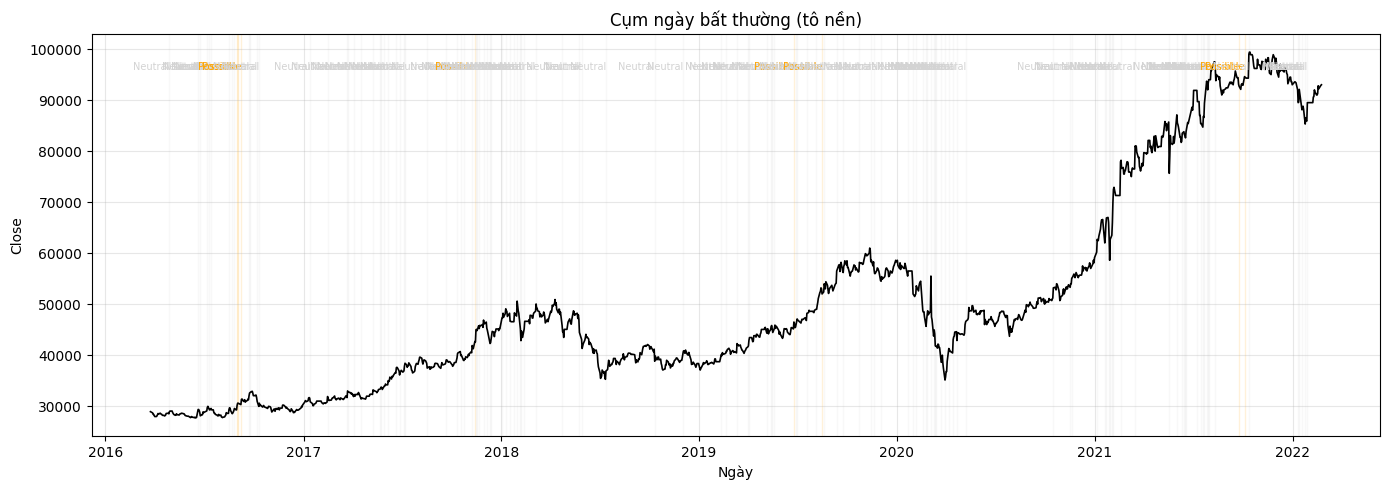

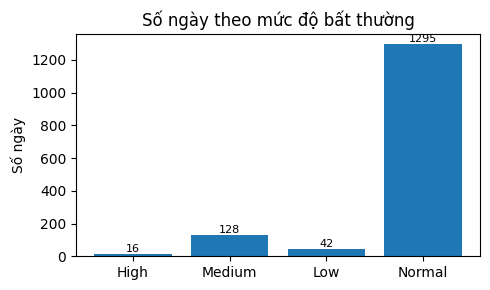

In [18]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

os.makedirs("plots", exist_ok=True)

# Chuẩn dữ liệu thời gian
plot_df = df_anom.sort_values("Date").reset_index(drop=True).copy()
# Flatten multi-level columns
plot_df.columns = [col[0] if isinstance(col, tuple) else col for col in plot_df.columns.values]

# ==== 1. Biểu đồ giá đóng cửa + highlight ngày bất thường =====================
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(plot_df["Date"], plot_df["Close"], label="Close", linewidth=1.2, color="black")

# tô màu High / Medium
high_mask = plot_df["anomaly_level"] == "High"
med_mask  = plot_df["anomaly_level"] == "Medium"

ax.scatter(plot_df.loc[high_mask,"Date"],
           plot_df.loc[high_mask,"Close"],
           color="red", s=25, label="High anomaly")

ax.scatter(plot_df.loc[med_mask,"Date"],
           plot_df.loc[med_mask,"Close"],
           color="orange", s=20, label="Medium anomaly")

# nếu có pump_dump thì đánh dấu vuông xanh
if "pump_dump" in plot_df.columns:
    pump_mask = plot_df["pump_dump"] == True
    ax.scatter(plot_df.loc[pump_mask,"Date"],
               plot_df.loc[pump_mask,"Close"],
               facecolors="none", edgecolors="green", s=60, linewidths=1.5,
               label="pump_dump")

ax.set_title("Giá đóng cửa và các ngày bất thường")
ax.set_xlabel("Ngày")
ax.set_ylabel("Giá đóng cửa")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/price_anomaly.png", dpi=200)
plt.show()

# ==== 2. Biểu đồ khối lượng và vol_z ==========================================
fig, ax1 = plt.subplots(figsize=(14,4))

ax1.bar(plot_df["Date"], plot_df["Volume"], alpha=0.4, label="Volume")
ax1.set_ylabel("Volume")
ax1.set_xlabel("Ngày")

ax2 = ax1.twinx()
ax2.plot(plot_df["Date"], plot_df["vol_z"], color="purple", linewidth=1.0, label="vol_z")
ax2.axhline(2.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("vol_z (z-score)")

ax1.set_title("Khối lượng giao dịch và vol_z (chuẩn hóa khối lượng)")
ax1.grid(alpha=0.3)

# gộp legend 2 trục
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="best")

plt.tight_layout()
plt.savefig("plots/volume_volz.png", dpi=200)
plt.show()

# ==== 3. Biểu đồ zoom từng cụm nghi ngờ =======================================
# vẽ Close và tô nền cho từng cluster Suspicious / Possible
if "clusters" in globals() and len(clusters) > 0:
    fig, ax = plt.subplots(figsize=(14,5))
    ax.plot(plot_df["Date"], plot_df["Close"], color="black", linewidth=1.2)
    ax.set_title("Cụm ngày bất thường (tô nền)")
    ax.set_xlabel("Ngày")
    ax.set_ylabel("Close")
    ax.grid(alpha=0.3)

    for _, row in clusters.iterrows():
        sd = pd.to_datetime(row["start_date"])
        ed = pd.to_datetime(row["end_date"])
        label = str(row.get("cluster_label","cluster"))
        color_map = {
            "Suspicious": "red",
            "Possible": "orange",
            "Watch": "yellow",
            "Neutral": "lightgray"
        }
        c = color_map.get(label, "lightgray")
        ax.axvspan(sd, ed, color=c, alpha=0.15)
        ax.text(ed, plot_df["Close"].max()*0.98,
                f"{label}",
                fontsize=7,
                ha="right",
                va="top",
                color=c)

    plt.tight_layout()
    plt.savefig("plots/clusters_overlay.png", dpi=200)
    plt.show()

# ==== 4. Thanh tóm tắt phân bổ mức độ bất thường ==============================
levels_order = ["High","Medium","Low","Normal"]
counts = plot_df["anomaly_level"].value_counts()
counts = counts.reindex(levels_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(counts.index, counts.values)
ax.set_title("Số ngày theo mức độ bất thường")
ax.set_ylabel("Số ngày")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("plots/anomaly_bar.png", dpi=200)
plt.show()